In [11]:
import pandas as pd

df = pd.read_csv("resultados_experimentacion.csv")
df

,problema,n,k,algoritmo,status,synthesis_time_ms,max_memory_mb,expanded_states,used_states,expanded_transitions,used_transitions,heuristic_time_ms
0,AT,1,1,MonolithicController,OK,3.0,9.56,6.0,6.0,8.0,8.0,0.0
1,AT,1,1,DirectedController,OK,45.0,15.41,6.0,6.0,8.0,8.0,0.0
2,AT,1,1,PORController,OK,30.0,15.41,6.0,6.0,8.0,8.0,0.0
3,AT,1,1,PORGeneralizedController,OK,34.0,10.94,6.0,6.0,8.0,8.0,0.0
4,AT,1,2,MonolithicController,OK,2.0,9.55,7.0,7.0,10.0,9.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
395,AT,10,9,PORGeneralizedController,OM,NaN,NaN,NaN,NaN,NaN,NaN,NaN
396,AT,10,10,MonolithicController,OM,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397,AT,10,10,DirectedController,OM,NaN,NaN,NaN,NaN,NaN,NaN,NaN
398,AT,10,10,PORController,OM,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
k = 6  # cambiá este valor

df_k = df[df["k"] == k]
tabla = df_k.pivot_table(index="n", columns="algoritmo", values="max_memory_mb")
tabla

algoritmo,DirectedController,MonolithicController,PORController,PORGeneralizedController
n,,,,
1,15.97,9.57,17.12,12.06
2,19.69,11.45,12.79,18.08
3,25.48,19.99,43.11,15.97
4,95.04,129.38,104.13,41.72
5,237.13,1413.12,886.06,641.09
6,2252.80,NaN,NaN,2990.08


In [13]:
casos_resueltos = (
    df[df["status"] == "OK"]
    .groupby("algoritmo")
    .size()
    .rename("casos_resueltos")
    .sort_values(ascending=False)
)
total = pd.Series({"TOTAL": casos_resueltos.sum()}, name="casos_resueltos")
pd.concat([casos_resueltos, total])

PORGeneralizedController     64
DirectedController           63
PORController                58
MonolithicController         56
TOTAL                       241
Name: casos_resueltos, dtype: int64

In [14]:
ok = df[df["status"] == "OK"]

max_n = (
    ok.sort_values(["algoritmo", "n", "k"], ascending=[True, False, False])
    .groupby("algoritmo")
    .first()[["n", "k"]]
    .rename(columns={"n": "max_n", "k": "k_en_max_n"})
)

max_k = (
    ok.sort_values(["algoritmo", "k", "n"], ascending=[True, False, False])
    .groupby("algoritmo")
    .first()[["k", "n"]]
    .rename(columns={"k": "max_k", "n": "n_en_max_k"})
)

max_n.join(max_k)

,max_n,k_en_max_n,max_k,n_en_max_k
algoritmo,,,,
DirectedController,10,1,10,6
MonolithicController,9,1,10,4
PORController,10,1,10,4
PORGeneralizedController,10,1,10,5


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_algoritmo(algoritmo):
    datos = df[df["algoritmo"] == algoritmo].copy()
    resueltos = datos[datos["status"] == "OK"][["n", "k"]]
    no_resueltos = datos[datos["status"] != "OK"][["n", "k"]]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(resueltos["n"], resueltos["k"], color="green", marker="o", s=120, label="Resuelto", zorder=3)
    ax.scatter(no_resueltos["n"], no_resueltos["k"], color="red", marker="x", s=120, linewidths=2, label="No resuelto", zorder=3)

    all_n = sorted(datos["n"].unique())
    all_k = sorted(datos["k"].unique())
    ax.set_xticks(all_n)
    ax.set_yticks(all_k)
    ax.set_xlabel("n")
    ax.set_ylabel("k")
    ax.set_title(algoritmo)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


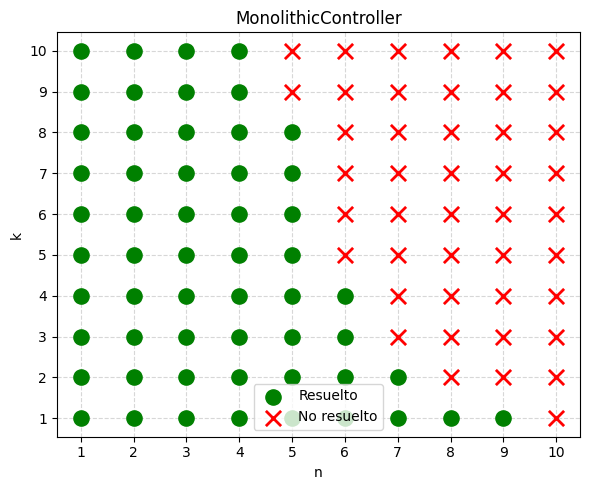

In [16]:

plot_algoritmo("MonolithicController")

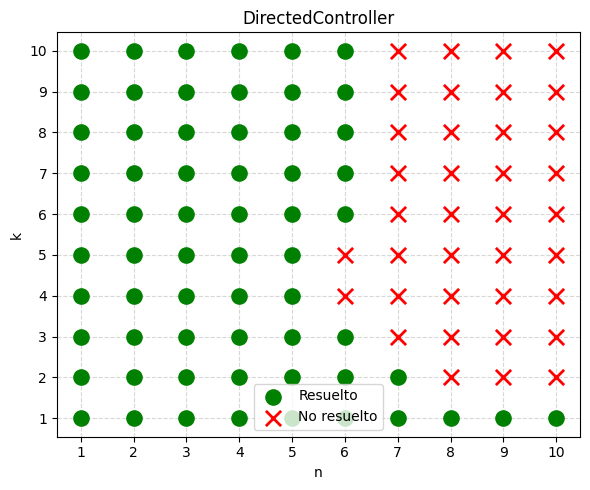

In [17]:
plot_algoritmo("DirectedController")

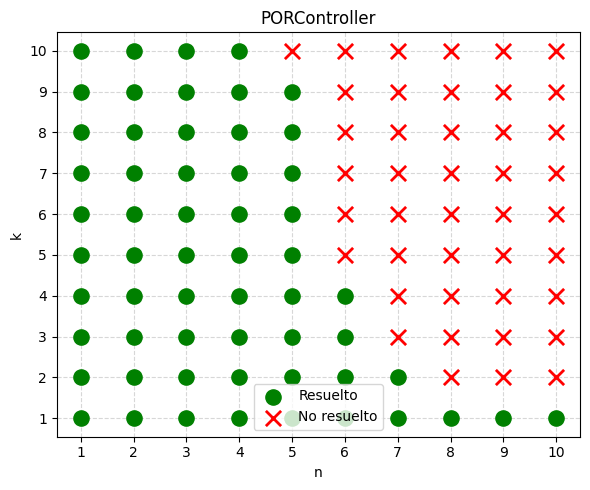

In [18]:
plot_algoritmo("PORController")

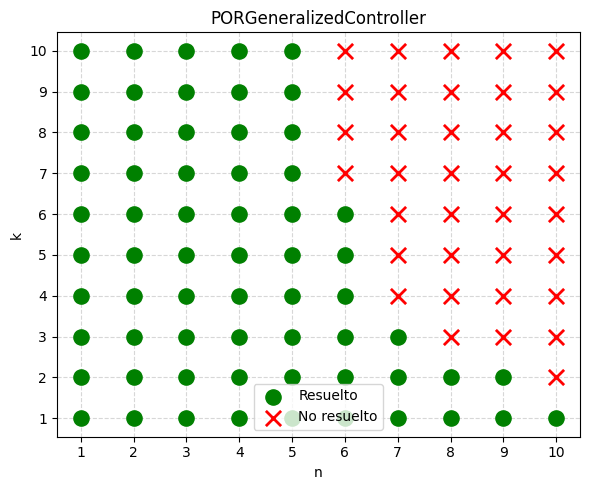

In [19]:
plot_algoritmo("PORGeneralizedController")

In [20]:
df[df["status"] == "OK"].groupby("algoritmo")["expanded_states"].max().rename("max_expanded_states").sort_values(ascending=False)

algoritmo
PORController               1099265.0
MonolithicController         388338.0
PORGeneralizedController     120466.0
DirectedController            34316.0
Name: max_expanded_states, dtype: float64

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm

ALGORITHMS = ["MonolithicController", "DirectedController", "PORController", "PORGeneralizedController"]

# Rampa secuencial (azul, claro -> oscuro) para codificar magnitud de memoria
BLUE_RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec",
             "#5598e7", "#3987e5", "#2a78d6", "#256abf", "#1c5cab",
             "#184f95", "#104281", "#0d366b"]
CMAP_MEMORIA = LinearSegmentedColormap.from_list("memoria_seq", BLUE_RAMP)
CMAP_MEMORIA.set_bad("#e0e0dc")  # gris = sin dato (OM/TO)

def plot_memoria_heatmap(problema="AT"):
    datos = df[df["problema"] == problema]
    todos_n = sorted(datos["n"].unique())
    todos_k = sorted(datos["k"].unique())

    # Misma escala de color en los 4 paneles -> permite comparar entre algoritmos
    norm = LogNorm(vmin=datos["max_memory_mb"].min(), vmax=datos["max_memory_mb"].max())

    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
    for ax, algo in zip(axes.flat, ALGORITHMS):
        tabla = (
            datos[datos["algoritmo"] == algo]
            .pivot_table(index="k", columns="n", values="max_memory_mb")
            .reindex(index=todos_k, columns=todos_n)
        )
        im = ax.imshow(tabla.values, origin="lower", cmap=CMAP_MEMORIA, norm=norm, aspect="auto")
        ax.set_xticks(range(len(todos_n)))
        ax.set_xticklabels(todos_n)
        ax.set_yticks(range(len(todos_k)))
        ax.set_yticklabels(todos_k)
        ax.set_xlabel("n")
        ax.set_ylabel("k")
        ax.set_title(algo)

    fig.colorbar(im, ax=axes, label="Memoria máxima usada (MB, escala log)", shrink=0.8)
    fig.suptitle(f"Uso de memoria en función de (n, k) — {problema}\n(gris = no resuelto: OOM o timeout)", y=0.99)
    plt.show()


In [ ]:
plot_memoria_heatmap()